# ==============================================
# 01. Imports & Settings
# ==============================================

In [11]:

import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, roc_curve
from scipy.stats import ttest_rel

import matplotlib.pyplot as plt
import seaborn as sns

np.random.seed(42)

print("Schritt 1: Imports & Settings erfolgreich ausgeführt.")
print("\n\n\n")


Schritt 1: Imports & Settings erfolgreich ausgeführt.






# ==============================================
# 02. Laden des Datensatzes
# ==============================================

In [12]:


def load_data(filepath):
    """Lädt den CSV-Datensatz."""
    data = pd.read_csv("titanic.csv")
    print(f"Shape: {data.shape}")
    display(data.head())
    print(data.info())
    print("Schritt 2: Datensatz erfolgreich geladen und angezeigt.")
    print("\n\n\n")
    return data




# ==============================================
# 03. Explorative Datenanalyse (EDA)
# ==============================================

In [ ]:
# ==============================================
# 03. EDA mit sinnvoll gruppierter Missing-Value-Übersicht
# ==============================================

def missing_values_by_group(df, column):
    """Fehlende Werte für eine Spalte nach Pclass, Survived, Sex, sinnvoll gruppiert und sortiert."""
    group = df.groupby(['Pclass', 'Survived', 'Sex'])[column].apply(lambda x: x.isnull().sum())
    total = df.groupby(['Pclass', 'Survived', 'Sex'])[column].size()
    mv_detail = pd.DataFrame({"Missing": group, "Total": total})
    mv_detail["Missing %"] = (mv_detail["Missing"] / mv_detail["Total"] * 100).round(2)
    mv_detail = mv_detail.reset_index()
    mv_detail = mv_detail[mv_detail["Missing"] > 0]
    mv_detail = mv_detail.sort_values(["Pclass", "Survived", "Sex"], ascending=[True, True, True])
    print(f"\nFehlende Werte in '{column}' (nach Klasse, Survived, Geschlecht):")
    display(mv_detail)

def explore_data(data):
    """EDA, u.a. mit übersichtlicher, gruppierter Missing-Value-Tabelle nach Pclass, Survived, Sex."""
    print("Basisstatistiken:")
    display(data.describe(include='all'))
    print("Verteilung 'Age':")
    data['Age'].hist(bins=30)
    plt.title('Verteilung Alter')
    plt.show()
    print("Survival Count:")
    sns.countplot(data=data, x='Survived')
    plt.title('Survival Count')
    plt.show()

    missing = data.isnull().sum()
    perc = (missing / len(data)) * 100
    mv_table = pd.DataFrame({
        "Missing Count": missing,
        "Missing %": perc.round(2)
    })
    print("\nÜbersicht fehlender Werte pro Spalte:")
    display(mv_table[mv_table["Missing Count"] > 0].sort_values("Missing %", ascending=False))

    # Sortierte Detail-Analyse für zentrale Felder
    for col in ['Age', 'Cabin', 'Embarked']:
        missing_values_by_group(data, col)


    # Nach deiner Datenladestufe und EDA:
numeric_cols = data.select_dtypes(include=['number']).columns.tolist()

corr = data[numeric_cols].corr()
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', linewidths=1, linecolor='grey')
plt.title('Korrelationsmatrix der numerischen Features')
plt.show()



    print("Schritt 3: EDA erfolgreich durchgeführt.")

# Beispiel im Ablauf:
# explore_data(data)


# ==============================================
# 04. Feature Engineering Pipeline
# ==============================================

In [14]:
class TitanicFeatureEngineer(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        # Titel extrahieren und Mapping für Medianberechnung
        X_copy = X.copy()
        X_copy["Title"] = X_copy["Name"].str.extract(r" ([A-Za-z]+)\.", expand=False)
        X_copy["Title"] = X_copy["Title"].map(self._map_title)
        self.title_median_age_ = (
            X_copy[["Title", "Age"]].dropna().groupby("Title")["Age"].median().to_dict()
        )
        self.global_median_age_ = X["Age"].median()
        return self

    @staticmethod
    def _map_title(title):
        if pd.isnull(title):
            return "Rare"
        mapping = {
            'Mr': 'Mr', 'Miss': 'Miss', 'Mrs': 'Mrs', 'Master': 'Master',
            'Dr': 'Rare', 'Rev': 'Rare', 'Col': 'Rare', 'Major': 'Rare',
            'Mlle': 'Miss', 'Mme': 'Mrs', 'Don': 'Rare', 'Dona': 'Rare',
            'Lady': 'Rare', 'Countess': 'Rare', 'Jonkheer': 'Rare', 'Sir': 'Rare',
            'Capt': 'Rare', 'Ms': 'Miss'
        }
        return mapping.get(title, title if title in ['Mr', 'Mrs', 'Miss', 'Master'] else "Rare")

    def transform(self, X):
        X = X.copy()

        # Titel extrahieren und mit Mapping vereinheitlichen
        X["Title"] = X["Name"].str.extract(r" ([A-Za-z]+)\.", expand=False)
        X["Title"] = X["Title"].map(self._map_title)

        # Alterslücken nach Titel-Median, sonst globaler Median
        X["Age"] = X.apply(
            lambda row: self.title_median_age_.get(row["Title"], self.global_median_age_)
                        if pd.isnull(row["Age"]) else row["Age"], axis=1)

        # Embarked Imputation (Ticket-Group und heuristische Regeln)
        for idx, row in X[X["Embarked"].isnull()].iterrows():
            tix_group_emb = X[(X["Ticket"] == row["Ticket"]) & X["Embarked"].notnull()]["Embarked"]
            if len(tix_group_emb):
                X.at[idx, "Embarked"] = tix_group_emb.mode().iloc[0]
                continue
            if row["Pclass"] == 1 and row["Fare"] > 70:
                X.at[idx, "Embarked"] = "C"
            elif row["Pclass"] == 1 and row["Fare"] > 30:
                X.at[idx, "Embarked"] = "S"
            elif row["Pclass"] == 3 and row["Fare"] < 15:
                X.at[idx, "Embarked"] = "Q"
            else:
                X.at[idx, "Embarked"] = "S"

        # Feature Engineering: FamilySize, IsAlone, TicketGroupSize, IsChild
        X["FamilySize"] = X["SibSp"].fillna(0) + X["Parch"].fillna(0) + 1
        X["IsAlone"] = (X["FamilySize"] == 1).astype(int)
        ticket_counts = X["Ticket"].value_counts()
        X["TicketGroupSize"] = X["Ticket"].map(ticket_counts)
        X["IsChild"] = (X["Age"] < 16).astype(int)

        # Spalten entfernen
        for col in ["PassengerId", "Name", "Cabin", "Ticket"]:
            if col in X.columns:
                X = X.drop(columns=col)
        return X


# ==============================================
# 05. Test-Train-Split
# ==============================================

In [15]:


def split_features_target(data, target_col):
    X = data.drop(columns=[target_col])
    y = data[target_col]
    print("Schritt 5:Feature/Target-Split erfolgreich durchgeführt.")
    print("\n\n\n")
    return X, y

def stratified_train_test_split(X, y, test_size=0.2, random_state=42):
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, stratify=y, random_state=random_state)
    print("Train/Test-Split (stratifiziert) erfolgreich durchgeführt.")
    print("\n\n\n")
    return X_train, X_test, y_train, y_test

# Beispiel:
# X, y = split_features_target(data, "Survived")
# X_train, X_test, y_train, y_test = stratified_train_test_split(X, y)


# ==============================================
# 06. Modell-Pipelines (KNN, Random Forest, Gradient Boosting)
# ==============================================

In [16]:


def get_preprocessor(num_features, cat_features):
    preprocessor = ColumnTransformer([
        ("num", StandardScaler(), num_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_features)
    ])
    print("Schritt 6.1:Preprocessor erfolgreich erstellt.")
    print("\n\n\n")
    return preprocessor

def build_pipeline(feature_engineer, preprocessor, model):
    print(f"Schritt 6.2:Pipeline für {model.__class__.__name__} erfolgreich erstellt.")
    print("\n\n\n")
    return Pipeline([
        ("featureengineering", feature_engineer),
        ("preprocessor", preprocessor),
        ("model", model)
    ])


# ==============================================
# 07. Cross-Validation (Basismodelle fitten und bewerten)
# ==============================================


In [17]:

def evaluate_base_models(X_train, y_train, num_features, cat_features):
    feature_engineer = TitanicFeatureEngineer()
    preprocessor = get_preprocessor(num_features, cat_features)
    models = [
        ("KNN", KNeighborsClassifier()),
        ("Random Forest", RandomForestClassifier(random_state=42)),
        ("Gradient Boosting", GradientBoostingClassifier(random_state=42)),
    ]

    for name, model in models:
        pipe = build_pipeline(feature_engineer, preprocessor, model)
        scores = cross_val_score(pipe, X_train, y_train, cv=5, scoring="accuracy")
        print(f"{name}: Mean CV Accuracy: {scores.mean():.3f}")
    print("Schritt 7: Cross-Validation für Basismodelle erfolgreich durchgeführt.")
    print("\n\n\n")

# Beispiel:
# num_features = ["Pclass", "Age", "SibSp", "Parch", "Fare",
#                 "FamilySize", "TicketGroupSize", "IsAlone", "IsChild"]
# cat_features = ["Sex", "Embarked", "Title"]
# evaluate_base_models(X_train, y_train, num_features, cat_features)


# ==============================================
# 08. Hyperparameter-Tuning mit GridSearchCV
# ==============================================

In [18]:


def get_gridsearches(num_features, cat_features):
    feature_engineer = TitanicFeatureEngineer()
    preprocessor = get_preprocessor(num_features, cat_features)
    knn_pipe = build_pipeline(feature_engineer, preprocessor, KNeighborsClassifier())
    rf_pipe = build_pipeline(feature_engineer, preprocessor, RandomForestClassifier(random_state=42))
    gb_pipe = build_pipeline(feature_engineer, preprocessor, GradientBoostingClassifier(random_state=42))

    knn_param_grid = {
        "model__n_neighbors": [3, 5, 7, 9,11,13],
        "model__weights": ["uniform", "distance"],
        "model__p": [1, 2]
    }
    rf_param_grid = {
        "model__n_estimators": [100, 200],
        "model__max_depth": [None, 5, 9],
        "model__min_samples_split": [2, 5],
        "model__min_samples_leaf": [1, 2],
        "model__criterion": ["gini", "entropy"]
    }
    gb_param_grid = {
        "model__n_estimators": [100, 200],
        "model__learning_rate": [0.05, 0.1, 0.2],
        "model__max_depth": [3, 5],
        "model__subsample": [0.8, 1.0]
    }

    cv = 5
    knn_gs = GridSearchCV(knn_pipe, knn_param_grid, cv=cv, scoring="accuracy", n_jobs=-1)
    rf_gs = GridSearchCV(rf_pipe, rf_param_grid, cv=cv, scoring="accuracy", n_jobs=-1)
    gb_gs = GridSearchCV(gb_pipe, gb_param_grid, cv=cv, scoring="accuracy", n_jobs=-1)

    print("Schritt 8: GridSearchCV-Objekte erfolgreich erstellt.")
    print("\n\n\n")
    return [("KNN", knn_gs), ("Random Forest", rf_gs), ("Gradient Boosting", gb_gs)]


# ==============================================
# 09. Evaluation der Modelle und finale Auswahl
# ==============================================

In [19]:
def fit_and_evaluate_gridsearches(gridsearch_list, X_train, y_train, X_test, y_test, num_features, cat_features):
    # Basismodelle (Default-Hyperparameter)
    base_results = []
    base_rocs = []
    feature_engineer = TitanicFeatureEngineer()
    preprocessor = get_preprocessor(num_features, cat_features)
    models = [
        ("KNN", KNeighborsClassifier()),
        ("Random Forest", RandomForestClassifier(random_state=42)),
        ("Gradient Boosting", GradientBoostingClassifier(random_state=42)),
    ]
    base_pipes = {}
    for name, model in models:
        pipe = Pipeline([
            ("featureengineering", feature_engineer),
            ("preprocessor", preprocessor),
            ("model", model),
        ])
        pipe.fit(X_train, y_train)
        y_pred = pipe.predict(X_test)
        test_acc = pipe.score(X_test, y_test)
        # ROC-AUC
        if hasattr(pipe.named_steps["model"], "predict_proba"):
            y_pred_proba = pipe.predict_proba(X_test)[:, 1]
            roc_auc = roc_auc_score(y_test, y_pred_proba)
            fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
            base_rocs.append({"name": name+" Default", "fpr": fpr, "tpr": tpr, "roc_auc": roc_auc})
        else:
            roc_auc = None
        base_results.append({
            "Name": name,
            "Status": "Default",
            "TestAcc": test_acc,
            "ROC-AUC": roc_auc
        })
        base_pipes[name] = pipe
    base_eval_df = pd.DataFrame(base_results)

    # Getunte Modelle (GridSearchCV)
    results = []
    rocs = []
    tuned_pipes = {}
    for name, gs in gridsearch_list:
        gs.fit(X_train, y_train)
        y_pred = gs.predict(X_test)
        test_acc = gs.score(X_test, y_test)
        # ROC-AUC
        if hasattr(gs, "predict_proba"):
            y_pred_proba = gs.predict_proba(X_test)[:, 1]
            roc_auc = roc_auc_score(y_test, y_pred_proba)
            fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
            rocs.append({"name": name+" Tuned", "fpr": fpr, "tpr": tpr, "roc_auc": roc_auc})
        else:
            roc_auc = None
        results.append({
            "Name": name,
            "Status": "Tuned",
            "TestAcc": test_acc,
            "ROC-AUC": roc_auc
        })
        tuned_pipes[name] = gs.best_estimator_
    eval_df = pd.DataFrame(results)

    # Tabellen zusammenführen für Vergleich
    comparison_df = pd.concat([base_eval_df, eval_df], ignore_index=True)

    # Modellvergleichsplot Test Accuracy (vor und nach Tuning)
    plt.figure(figsize=(10,6))
    sns.barplot(x='Name', y='TestAcc', hue='Status', data=comparison_df)
    plt.title('Modellvergleich: Test Accuracy, Default vs Tuned')
    plt.ylabel('Test Accuracy')
    plt.xlabel('Modell')
    plt.ylim(0.7, 1.0)
    plt.legend(title='Status')
    plt.show()

    # Modellvergleichsplot ROC-AUC (vor und nach Tuning)
    if not comparison_df["ROC-AUC"].isnull().all():
        plt.figure(figsize=(10,6))
        sns.barplot(x='Name', y='ROC-AUC', hue='Status', data=comparison_df)
        plt.title('Modellvergleich: ROC-AUC, Default vs Tuned')
        plt.ylabel('ROC-AUC')
        plt.xlabel('Modell')
        plt.ylim(0.7, 1.0)
        plt.legend(title='Status')
        plt.show()

    # Gemeinsamer ROC-Plot für alle Modelle
    plt.figure(figsize=(8,6))
    for entry in base_rocs + rocs:
        plt.plot(entry['fpr'], entry['tpr'], label=f"{entry['name']} (AUC={entry['roc_auc']:.2f})")
    plt.plot([0,1],[0,1],'k--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curves: Modellvergleich Default & Tuned')
    plt.legend(loc='lower right')
    plt.show()

    # Feature Importances für alle Baummodelle (Default & Tuned)
    for name in ['Random Forest', 'Gradient Boosting']:
        for status, pipe in zip(['Default','Tuned'], [base_pipes.get(name), tuned_pipes.get(name)]):
            if pipe is not None and hasattr(pipe.named_steps['model'], 'feature_importances_'):
                feat_imp = pipe.named_steps['model'].feature_importances_
                feat_names = pipe.named_steps['preprocessor'].get_feature_names_out()
                imp_df = pd.DataFrame({'Feature': feat_names, 'Importance': feat_imp})
                imp_df = imp_df.sort_values('Importance', ascending=False)
                plt.figure(figsize=(10,6))
                sns.barplot(x='Importance', y='Feature', data=imp_df.head(15))
                plt.title(f'Feature Importance: {name} ({status})')
                plt.xlabel('Wichtigkeit')
                plt.ylabel('Feature')
                plt.show()

    # ---- p-Test zur Modellverbesserung ----
    print("\n-- Statistischer Modellvergleich (p-value, paired t-Test über CV auf Trainingsdaten) --")
    cv = 5
    for name, base_pipe in base_pipes.items():
        tuned_pipe = tuned_pipes.get(name)
        if tuned_pipe is None:
            continue
        scores_default = cross_val_score(base_pipe, X_train, y_train, cv=cv, scoring='accuracy')
        scores_tuned = cross_val_score(tuned_pipe, X_train, y_train, cv=cv, scoring='accuracy')
        t_stat, p_val = ttest_rel(scores_default, scores_tuned)
        print(f"{name}: Mittelwert Default = {scores_default.mean():.3f}, Tuned = {scores_tuned.mean():.3f}, p-wert = {p_val:.4f}")
        if p_val < 0.05:
            print("-> Unterschied signifikant!")
        else:
            print("-> Unterschied nicht signifikant.")
    return comparison_df

Shape: (891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB
None
Schritt 2: Datensatz erfolgreich geladen und angezeigt.




Basisstatistiken:


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
count,891.000000,891.000000,891.000000,891,891,714.000000,891.000000,891.000000,891,891.000000,204,889
unique,NaN,NaN,NaN,891,2,NaN,NaN,NaN,681,NaN,147,3
top,NaN,NaN,NaN,"Braund, Mr. Owen Harris",male,NaN,NaN,NaN,347082,NaN,G6,S
freq,NaN,NaN,NaN,1,577,NaN,NaN,NaN,7,NaN,4,644
mean,446.000000,0.383838,2.308642,NaN,NaN,29.699118,0.523008,0.381594,NaN,32.204208,NaN,NaN
std,257.353842,0.486592,0.836071,NaN,NaN,14.526497,1.102743,0.806057,NaN,49.693429,NaN,NaN
min,1.000000,0.000000,1.000000,NaN,NaN,0.420000,0.000000,0.000000,NaN,0.000000,NaN,NaN
25%,223.500000,0.000000,2.000000,NaN,NaN,20.125000,0.000000,0.000000,NaN,7.910400,NaN,NaN
50%,446.000000,0.000000,3.000000,NaN,NaN,28.000000,0.000000,0.000000,NaN,14.454200,NaN,NaN
75%,668.500000,1.000000,3.000000,NaN,NaN,38.000000,1.000000,0.000000,NaN,31.000000,NaN,NaN


Verteilung 'Age':


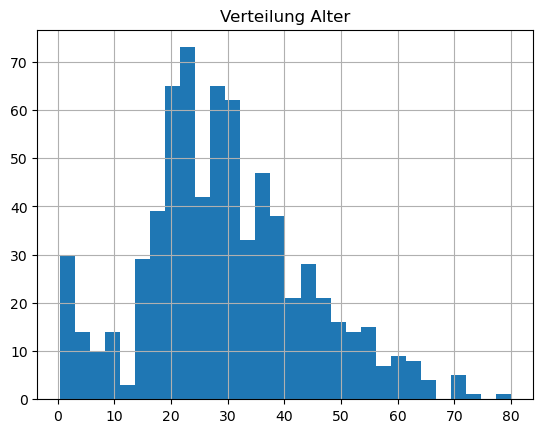

Survival Count:


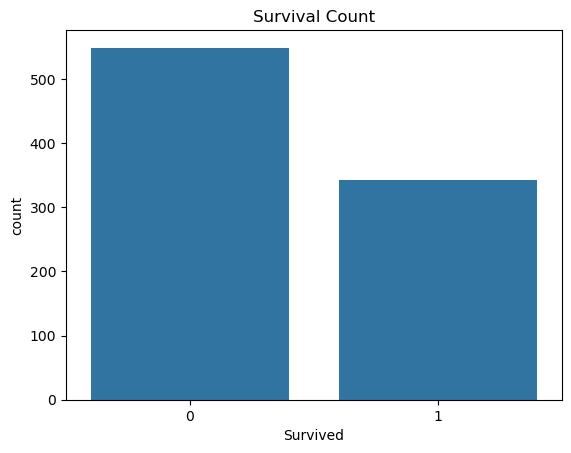


Übersicht fehlender Werte pro Spalte:


,Missing Count,Missing %
Cabin,687,77.10
Age,177,19.87
Embarked,2,0.22



Fehlende Werte in 'Age' (nach Klasse, Survived, Geschlecht):


,Pclass,Survived,Sex,Missing,Total,Missing %
1,1,0,male,16,77,20.78
2,1,1,female,9,91,9.89
3,1,1,male,5,45,11.11
5,2,0,male,7,91,7.69
6,2,1,female,2,70,2.86
7,2,1,male,2,17,11.76
8,3,0,female,17,72,23.61
9,3,0,male,85,300,28.33
10,3,1,female,25,72,34.72
11,3,1,male,9,47,19.15



Fehlende Werte in 'Cabin' (nach Klasse, Survived, Geschlecht):


,Pclass,Survived,Sex,Missing,Total,Missing %
1,1,0,male,21,77,27.27
2,1,1,female,13,91,14.29
3,1,1,male,6,45,13.33
4,2,0,female,5,6,83.33
5,2,0,male,89,91,97.80
6,2,1,female,61,70,87.14
7,2,1,male,13,17,76.47
8,3,0,female,70,72,97.22
9,3,0,male,296,300,98.67
10,3,1,female,68,72,94.44



Fehlende Werte in 'Embarked' (nach Klasse, Survived, Geschlecht):


,Pclass,Survived,Sex,Missing,Total,Missing %
2,1,1,female,2,91,2.2


Schritt 3: EDA erfolgreich durchgeführt.
Schritt 5:Feature/Target-Split erfolgreich durchgeführt.




Train/Test-Split (stratifiziert) erfolgreich durchgeführt.




Schritt 6.1:Preprocessor erfolgreich erstellt.




Schritt 6.2:Pipeline für KNeighborsClassifier erfolgreich erstellt.




KNN: Mean CV Accuracy: 0.796
Schritt 6.2:Pipeline für RandomForestClassifier erfolgreich erstellt.




Random Forest: Mean CV Accuracy: 0.799
Schritt 6.2:Pipeline für GradientBoostingClassifier erfolgreich erstellt.




Gradient Boosting: Mean CV Accuracy: 0.818
Schritt 7: Cross-Validation für Basismodelle erfolgreich durchgeführt.




Schritt 6.1:Preprocessor erfolgreich erstellt.




Schritt 6.2:Pipeline für KNeighborsClassifier erfolgreich erstellt.




Schritt 6.2:Pipeline für RandomForestClassifier erfolgreich erstellt.




Schritt 6.2:Pipeline für GradientBoostingClassifier erfolgreich erstellt.




Schritt 8: GridSearchCV-Objekte erfolgreich erstellt.




Schritt 6.1:Preprocessor erfolgreich erst

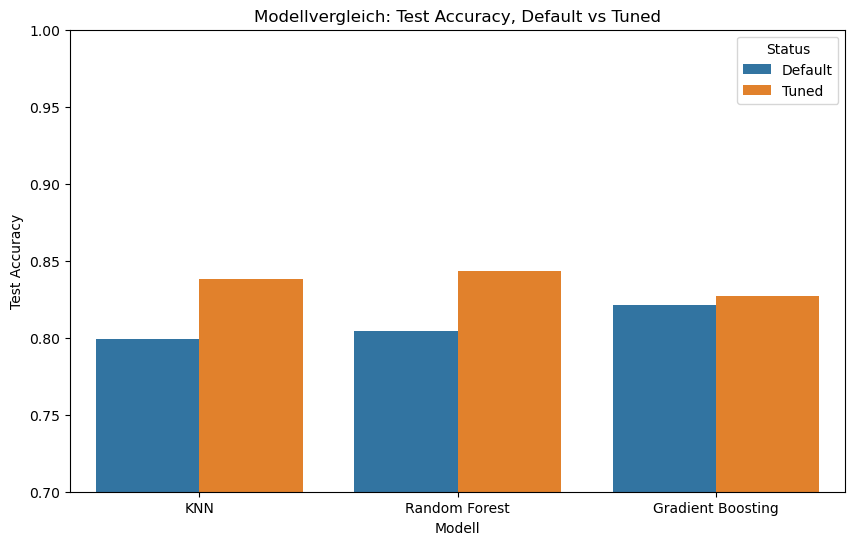

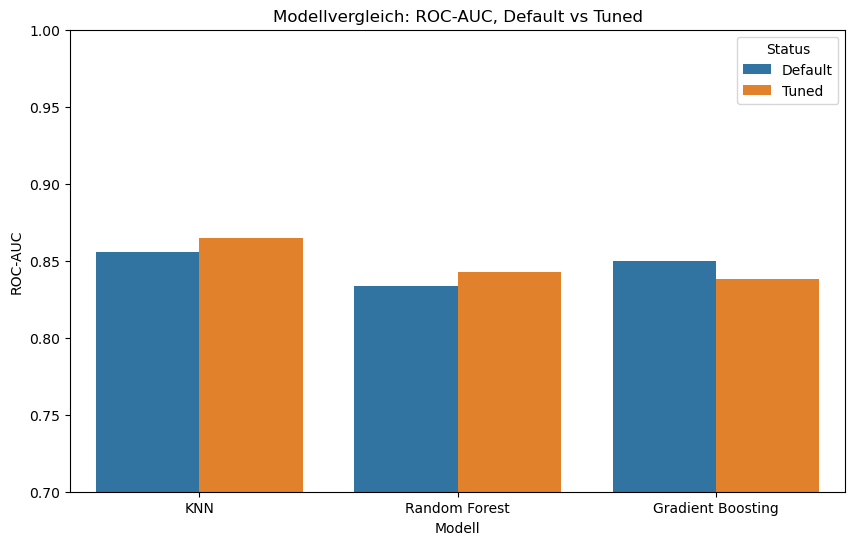

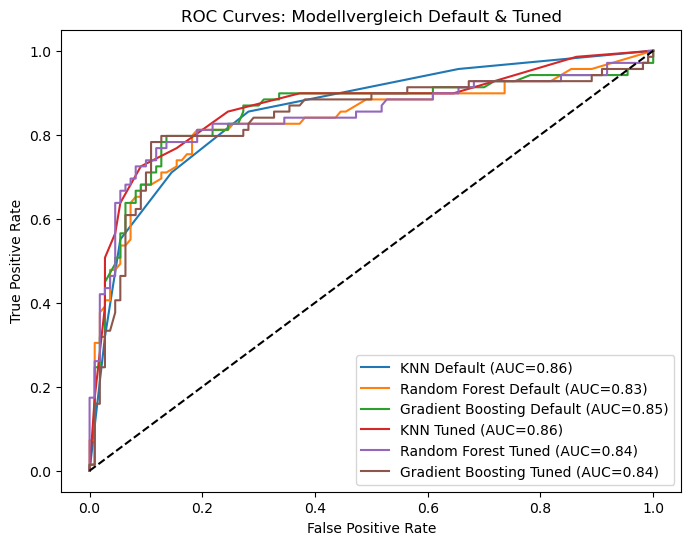

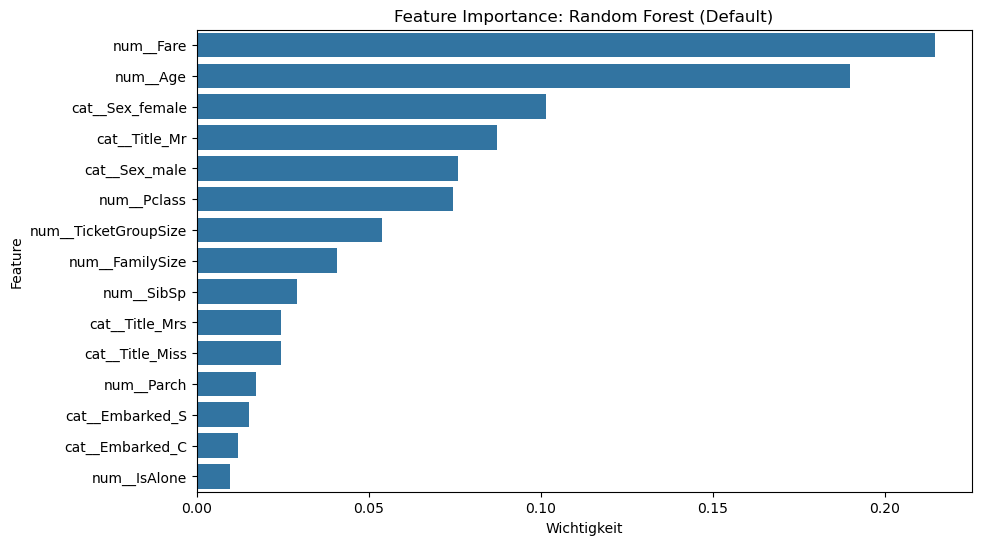

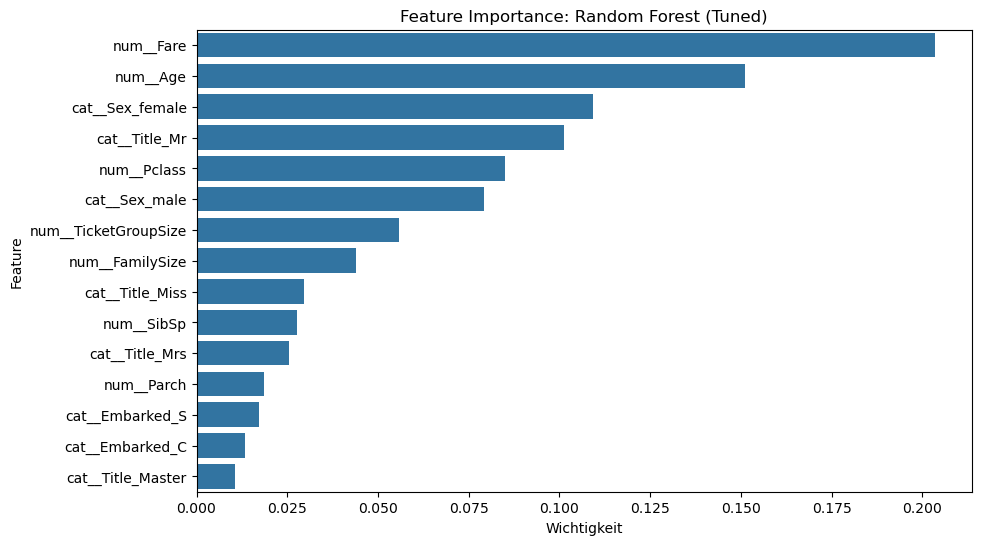

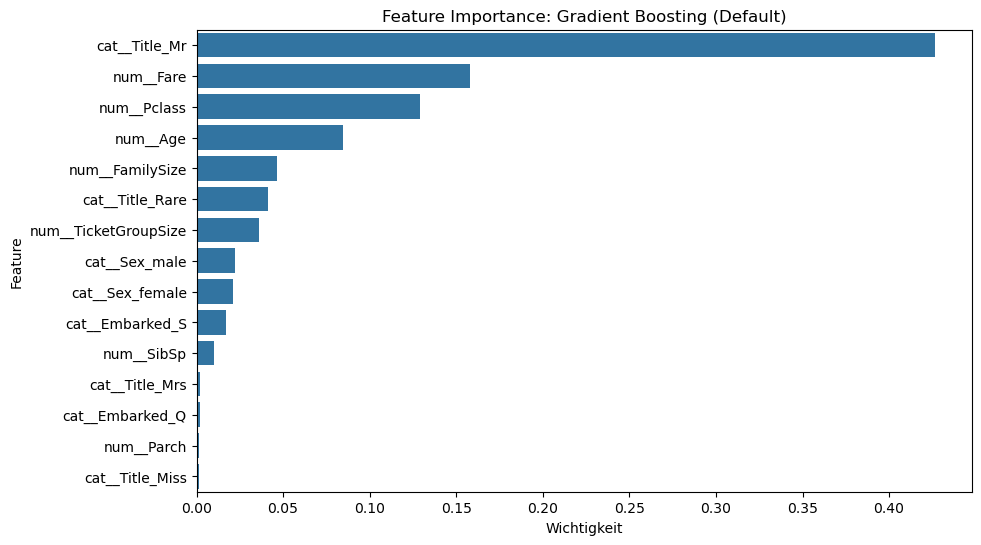

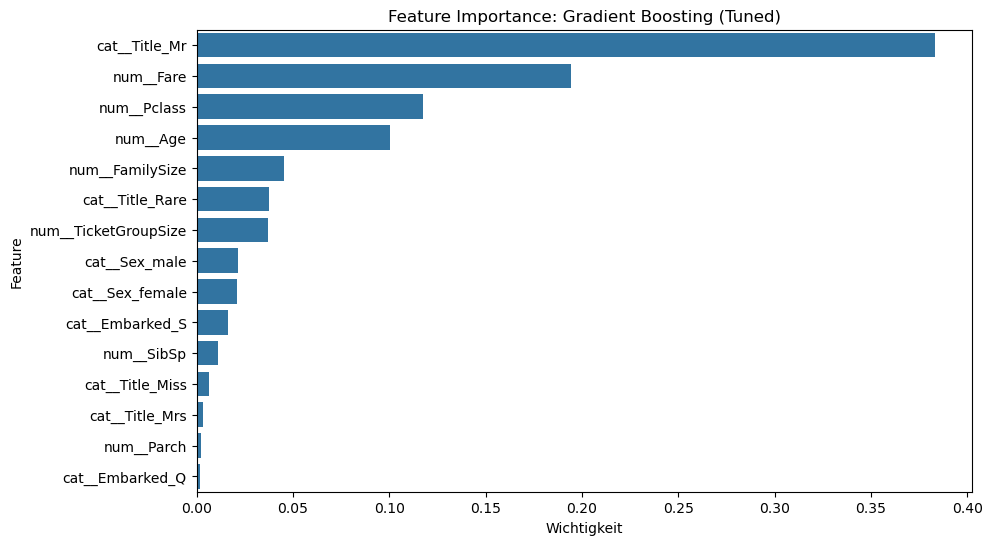


-- Statistischer Modellvergleich (p-value, paired t-Test über CV auf Trainingsdaten) --
KNN: Mittelwert Default = 0.796, Tuned = 0.830, p-wert = 0.0076
-> Unterschied signifikant!
Random Forest: Mittelwert Default = 0.799, Tuned = 0.827, p-wert = 0.1057
-> Unterschied nicht signifikant.
Gradient Boosting: Mittelwert Default = 0.818, Tuned = 0.825, p-wert = 0.3497
-> Unterschied nicht signifikant.


,Name,Status,TestAcc,ROC-AUC
0,KNN,Default,0.798883,0.855797
1,Random Forest,Default,0.804469,0.833399
2,Gradient Boosting,Default,0.821229,0.850066
3,KNN,Tuned,0.837989,0.864756
4,Random Forest,Tuned,0.843575,0.842885
5,Gradient Boosting,Tuned,0.826816,0.838142


Komplettlauf erfolgreich abgeschlossen und Ergebnisse angezeigt.






Exception ignored in: <function ResourceTracker.__del__ at 0x77084d8bbce0>
Traceback (most recent call last):
  File "/home/developer/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 84, in __del__
  File "/home/developer/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 93, in _stop
  File "/home/developer/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 118, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x7f5b46fb3ce0>
Traceback (most recent call last):
  File "/home/developer/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 84, in __del__
  File "/home/developer/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 93, in _stop
  File "/home/developer/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 118, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function 

In [20]:
# ==============================================
# Main: Gesamter Workflow Schritt für Schritt
# ==============================================

# --- 1. Daten laden ---
data = load_data("titanic.csv")  # Pfad ggf. anpassen

# --- 2. EDA ---
explore_data(data)

# --- 3. Features/Target Split & Train/Test-Split ---
X, y = split_features_target(data, "Survived")
X_train, X_test, y_train, y_test = stratified_train_test_split(X, y)

# --- 4. Feature-Listen für Preprocessing ---
num_features = ["Pclass", "Age", "SibSp", "Parch", "Fare",
                "FamilySize", "TicketGroupSize", "IsAlone", "IsChild"]
cat_features = ["Sex", "Embarked", "Title"]

# --- 5. Basismodelle CV ---
evaluate_base_models(X_train, y_train, num_features, cat_features)

# --- 6. Hyperparameter-Tuning mit allen drei Modellen ---
gridsearches = get_gridsearches(num_features, cat_features)
evaluation = fit_and_evaluate_gridsearches(
    gridsearches, X_train, y_train, X_test, y_test, num_features, cat_features
)

# --- 7. Ergebnisse anzeigen ---
display(evaluation)

print("Komplettlauf erfolgreich abgeschlossen und Ergebnisse angezeigt.")
print("\n\n\n")

